<a href="https://colab.research.google.com/github/SAKURA-hub69/-/blob/main/%E8%A9%A6%E9%A8%93%E7%A8%AE%E9%9B%A3%E6%98%93%E5%BA%A6%E5%88%86%E6%9E%90_ops20_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("試験種の講座コード(4桁)+科目コード(2桁)を入力してください。複数入力の場合は半角スペースをあけてください。\n東大文系英語なら140810とか。東大文系と東大理系は講座コード1408で統一してあります。")
KODE_list = list(input().split())
#相対パスの設定
#input_path = "./2020/opstts_details_2020.xlsx"

試験種の講座コード(4桁)+科目コード(2桁)を入力してください。複数入力の場合は半角スペースをあけてください。
東大文系英語なら140810とか。東大文系と東大理系は講座コード1408で統一してあります。
140810


In [ ]:
from google import colab
from glob import glob
import pandas as pd
from google.colab import files

colab.drive.mount('/content/gdrive')
print("めっちゃ時間かかります。辛抱強く待ってください。")


input_paths = glob('/content/gdrive/My Drive/復習の指針/analysis/opstts_details_2020.xlsx', recursive=True)
assert len(input_paths) == 1, (
    'opstts_details_2020.xlsxは1つである必要があります。\n'
    '見つかったパス : \n{}'.format('\n'.join(input_paths))
)
input_path = input_paths[0]

#データ読み込み、3分。。
df = pd.read_excel(input_path, dtype=str, usecols=["ANSERSHEET_ID","KOZA_CODE","JUKEN_KAMOKU_ID","SHIKEN_NENDO","KAISU","MAX_MARKS","MARKS","EXAMINER_ID"])
print("データ読み込み完了")
print(df.head())

In [ ]:
for KODE in KODE_list:
  df_out = pd.DataFrame()
  KOZA_KODE = KODE[:4]
  JUKEN_KAMOKU_ID = KODE[4:]
  output_path = './' + KODE + '.csv'

  for nendo in range(20, 10, -1):
    #試験種絞り込み,回数は1回目のみ
    nendo = str(nendo)
    df_extract = df.query('KOZA_CODE == @KOZA_KODE & JUKEN_KAMOKU_ID == @JUKEN_KAMOKU_ID & SHIKEN_NENDO == @nendo & KAISU == "1"')
    df_extract = df_extract.dropna(how='any')#不備答案を除く
    df_extract = df_extract.query('EXAMINER_ID != "team894 "')#team894返却を除く,team894の後ろに半角スペースが謎にある
    df_extract = df_extract.drop_duplicates("ANSERSHEET_ID")#二重登録を除く
    df_extract = df_extract.astype({'MAX_MARKS':'int64', 'MARKS':'int64'})
    df_extract = df_extract.reset_index(drop=True)#一応index番号を振り直す


    info_2 = df_extract['MARKS'].quantile([i / 100 for i in range(95, -1, -5)])#5%タイルのseries作成
    info_1 = [df_extract['MAX_MARKS'].max(), len(df_extract), df_extract['MARKS'].mean(), df_extract['MARKS'].std(), df_extract['MARKS'].min(), df_extract['MARKS'].max()]
    info_1 = pd.Series(info_1, index=['配点', 'サンプル数','平均','標準偏差','最低点','最高点'])#平均などのseries作成
    info = pd.concat([info_1, info_2])#結合
    info = info.rename(nendo)#列名を変更
    df_out = pd.concat([df_out,info],axis=1)#横に結合していく

  df_out.to_csv(output_path, encoding='utf-8')
  files.download(output_path)
print('ファイルダウンロードが完了しました。')#全てダウンロードされない場合があるので、その時はダウンロードフォルダから手動でお願いします。

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ファイルダウンロードが完了しました。


*↓最初に指定した試験種のヒストグラムが出ます*


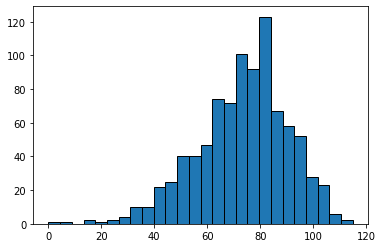

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
x = df_extract['MARKS']
# ヒストグラムを表示する
plt.hist(x, bins='auto',ec='black');

In [ ]:
#違う形式ver

df_ans = pd.DataFrame()

for KODE in KODE_list:
  df_out = pd.DataFrame()
  KOZA_KODE = KODE[:4]
  JUKEN_KAMOKU_ID = KODE[4:]
  output_path = './ダウンロード/analize_ops20_' + KODE + '.csv'
  df_extract = df.query('KOZA_CODE == @KOZA_KODE & JUKEN_KAMOKU_ID == @JUKEN_KAMOKU_ID & KAISU == "1"')

  for nendo in range(20, 10, -1):
    #試験種絞り込み,回数は1回目のみ
    nendo = str(nendo)
    df_nendo = df_extract.query('SHIKEN_NENDO == @nendo')
    df_nendo = df_nendo.dropna(how='any')#不備答案を除く
    df_nendo = df_nendo.query('EXAMINER_ID != "team894 "')#team894返却を除く,team894の後ろに半角スペースが謎にある
    df_nendo = df_nendo.drop_duplicates("ANSERSHEET_ID")#二重登録を除く
    df_nendo = df_nendo.astype({'MAX_MARKS':'int64', 'MARKS':'int64'})
    df_nendo = df_nendo.reset_index(drop=True)#一応index番号を振り直す

    df_T = df_nendo.describe().T[['count','mean','std']]
    info_2 = df_nendo.quantile([i / 100 for i in range(100, -1, -5)])
    info_2 = info_2.T
    df_merge = pd.concat([df_T, info_2], axis=1)
    df_merge = df_merge[df_merge.index == 'MARKS']
    df_merge = df_merge.rename(index={'MARKS': str(20) + nendo})
    df_merge.insert(0,'KAMOKU', JUKEN_KAMOKU_ID)
    df_merge.insert(0,'CODE', KOZA_KODE)


    df_out = pd.concat([df_out,df_merge],axis=0)
  df_ans = pd.concat([df_ans, df_out],axis=0)

df_ans.to_csv(output_path, encoding='utf-8')
files.download(output_path)
print('ファイルダウンロードが完了しました。')#全てダウンロードされない場合があるので、その時はダウンロードフォルダから手動でお願いします。

FileNotFoundError: ignored